## Machine Learning for Classification and Regression

## Classification 

In this section, classification is performed using the **Iris dataset**.

Four machine learning models are implemented and evaluated:
- Logistic Regression 
- Support Vector Machine (SVM)
- Decision Tree
- Multi-Layer Perceptron (Neural Network)

A **70/30 train-test split** is used for initial evaluation and **5-Fold Cross Validation** to compare model performance.

### Data Preparation

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
  
df = pd.read_csv("data/iris.csv")
X = df.drop("Class", axis = 1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 1, stratify=y)

In [2]:
# Cross-Validation Setup
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

k = 5
cv = StratifiedKFold(n_splits= k, shuffle= True, random_state=42)

# Helper function to print CV scores
def print_cv_scores(model_name, scores):
    print(f"{model_name} {k}-Fold CV Scores Results:")
    print(f"    Mean Accuracy: {scores.mean():.3f}")
    print(f"    Standard Deviation: {scores.std():.3f}\n")

### Data Visualisation
A graphical representation of the Iris dataset to see existing feature relationships and class separability.
- The scatter plots show how two features relate to each other.
- The histograms shows the distribution of a single feature by class.

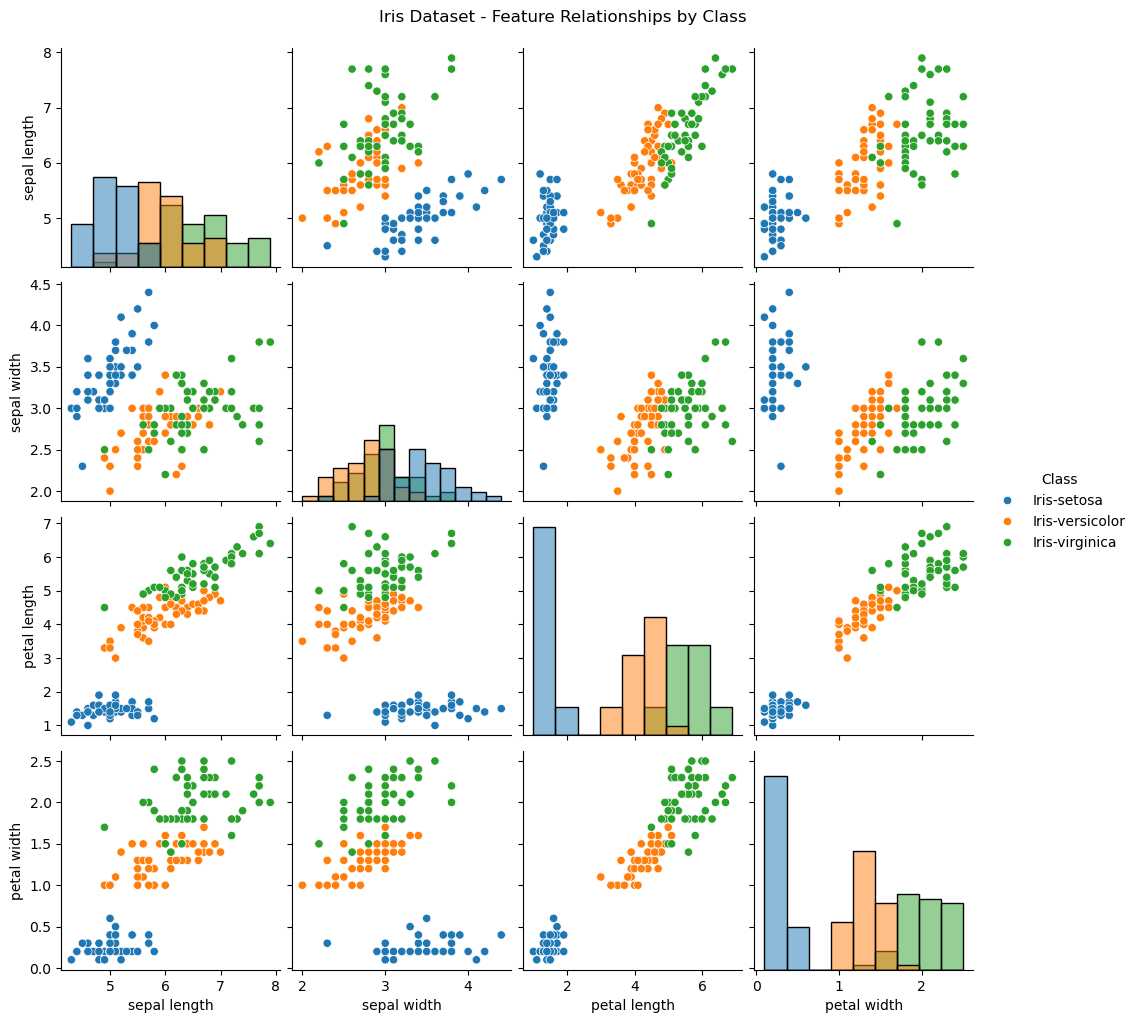

In [3]:
import seaborn as sns

sns.pairplot(df, hue="Class", diag_kind="hist")
plt.suptitle("Iris Dataset - Feature Relationships by Class", y=1.02)
plt.show()

### Model Training and Evaluation

#### Logistic Regression

In [4]:
# Logistic Regression Classifier 
from sklearn.linear_model import LogisticRegression

# Create the model
log_reg_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=0))
])

# Train the model on the training datas
log_reg_model.fit(X_train, y_train)

# Evaluate the model on the test data
test_score = log_reg_model.score(X_test, y_test)
print('Logistic Regression Test Accuracy: {:03.3f}'.format(test_score))

# Perform K-Fold Cross-Validation
log_reg_cv_scores = cross_val_score(log_reg_model, X, y, cv=cv, scoring='accuracy')
print_cv_scores("Logistic Regression", log_reg_cv_scores)

Logistic Regression Test Accuracy: 0.978
Logistic Regression 5-Fold CV Scores Results:
    Mean Accuracy: 0.953
    Standard Deviation: 0.045



#### Support Vector Machine (SVM)

In [5]:
# Support Vector Machine
from sklearn import svm

# Create the model
svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', svm.SVC(C=1.0, kernel='rbf', degree=3, gamma='scale', probability=True, random_state=1))
])

# Train the model on the training data
svm_model.fit(X_train,y_train)

# Evaluate the model on the test data
test_score = svm_model.score(X_test, y_test)
print('SVM Test Accuracy: {:03.3f}'.format(test_score))

# Perform K-Fold Cross-Validation
svm_cv_scores = cross_val_score(svm_model, X, y, cv=cv, scoring='accuracy')
print_cv_scores("SVM", svm_cv_scores)

SVM Test Accuracy: 0.978
SVM 5-Fold CV Scores Results:
    Mean Accuracy: 0.960
    Standard Deviation: 0.039



#### Decision Tree

In [6]:
# Decision Tree
from sklearn import tree

# Create the model
tree_model = tree.DecisionTreeClassifier()

# Train the model on the training data
tree_model.fit(X_train, y_train)

# Evaluate the model on the test data
test_score = tree_model.score(X_test, y_test)
print('Decision Tree Test Accuracy: {:03.3f}'.format(test_score))

# Perform K-Fold Cross-Validation
tree_cv_scores = cross_val_score(tree_model, X, y, cv=cv, scoring='accuracy')
print_cv_scores("Decision Tree", tree_cv_scores)

Decision Tree Test Accuracy: 0.978
Decision Tree 5-Fold CV Scores Results:
    Mean Accuracy: 0.953
    Standard Deviation: 0.034



#### Multi-Layer Perceptron (Neural Network)

In [7]:
# MLP
from sklearn.neural_network import MLPClassifier

# Create the model
mlp_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(random_state=1, max_iter=3000))
])

# Train the model on the training data
mlp_model.fit(X_train, y_train)
# Predict probabilities return the predicted probability for each class
mlp_model.predict_proba(X_test)

# Evaluate the model on the test data
test_score = mlp_model.score(X_test,y_test)
print('MLP Test Accuracy: {:03.3f}'.format(test_score))

# Perform K-Fold Cross-Validation
mlp_cv_scores = cross_val_score(mlp_model, X, y, cv=cv, scoring='accuracy')
print_cv_scores("MLP", mlp_cv_scores)

MLP Test Accuracy: 0.978
MLP 5-Fold CV Scores Results:
    Mean Accuracy: 0.953
    Standard Deviation: 0.045



### Classification Evaluation

The table below summarises the average accuracy and standard deviation across 5 cross-validation folds for each model.

A bar chart shows the relative performance.

In [8]:
# Summary Table
summary = pd.DataFrame([
    {"Model": "Logistic Regression", "K": k, "Mean Accuracy": log_reg_cv_scores.mean(),  "Std Dev": log_reg_cv_scores.std()},
    {"Model": "SVM (RBF)",           "K": k, "Mean Accuracy": svm_cv_scores.mean(), "Std Dev": svm_cv_scores.std()},
    {"Model": "Decision Tree",        "K": k, "Mean Accuracy": tree_cv_scores.mean(),"Std Dev": tree_cv_scores.std()},
    {"Model": "MLP",                  "K": k, "Mean Accuracy": mlp_cv_scores.mean(), "Std Dev": mlp_cv_scores.std()},
]).sort_values("Mean Accuracy", ascending=False).reset_index(drop=True)

summary

,Model,K,Mean Accuracy,Std Dev
0,SVM (RBF),5,0.960000,0.038873
1,Decision Tree,5,0.953333,0.033993
2,Logistic Regression,5,0.953333,0.045216
3,MLP,5,0.953333,0.045216


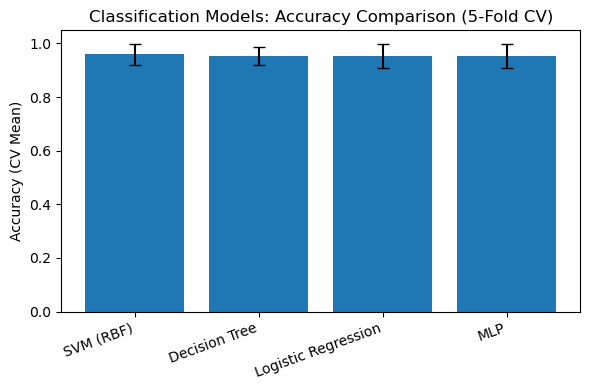

In [9]:
plt.figure(figsize=(6,4))
plt.bar(summary["Model"], summary["Mean Accuracy"], yerr=summary["Std Dev"], capsize=4)
plt.ylabel("Accuracy (CV Mean)")
plt.title(f"Classification Models: Accuracy Comparison ({k}-Fold CV)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Regression

In this section, regression is performed using the **Real Estate Valuation dataset**.

Four machine learning models are implemented and evaluated:
- Linear Regression 
- Support Vector Regression (SVR)
- Decision Tree
- Multi-Layer Perceptron (Neural Network)

A **70/30 train-test split** is used for initial evaluation, while **5-Fold Cross Validation** with **Root Mean Squared Error (RMSE)** to compare model performance.

### Data preparation

In [10]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
  
df = pd.read_csv("data/real-estate-valuation.csv")
df_prep = df.drop(['No', 'X1 transaction date'], axis=1)
X = df_prep.drop('Y house price of unit area', axis=1)
y = df_prep["Y house price of unit area"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
# Cross-Validation Setup
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=42)

# Helper function to print CV scores
def print_cv_scores(model_name, scores):
    print(f"{model_name} {k}-Fold CV Scores Results:")
    print(f"    Mean RMSE: {scores.mean():.3f}")
    print(f"    Standard Deviation of RMSE: {scores.std():.3f}\n")

### Data Visualisation
This is a graphical representation of the Real Estate dataset in the data exploration phase where we evaluate existing feature relationships and determine correlations.
- The heatmap shows how two features correlate with each other.
- When the cell is a deep red, there is a strong positive correlation
- When the cell is a deep blue, there is a strong negative correlation
- Finally, When the cell is greyish/white is means there is a weak or no correlation

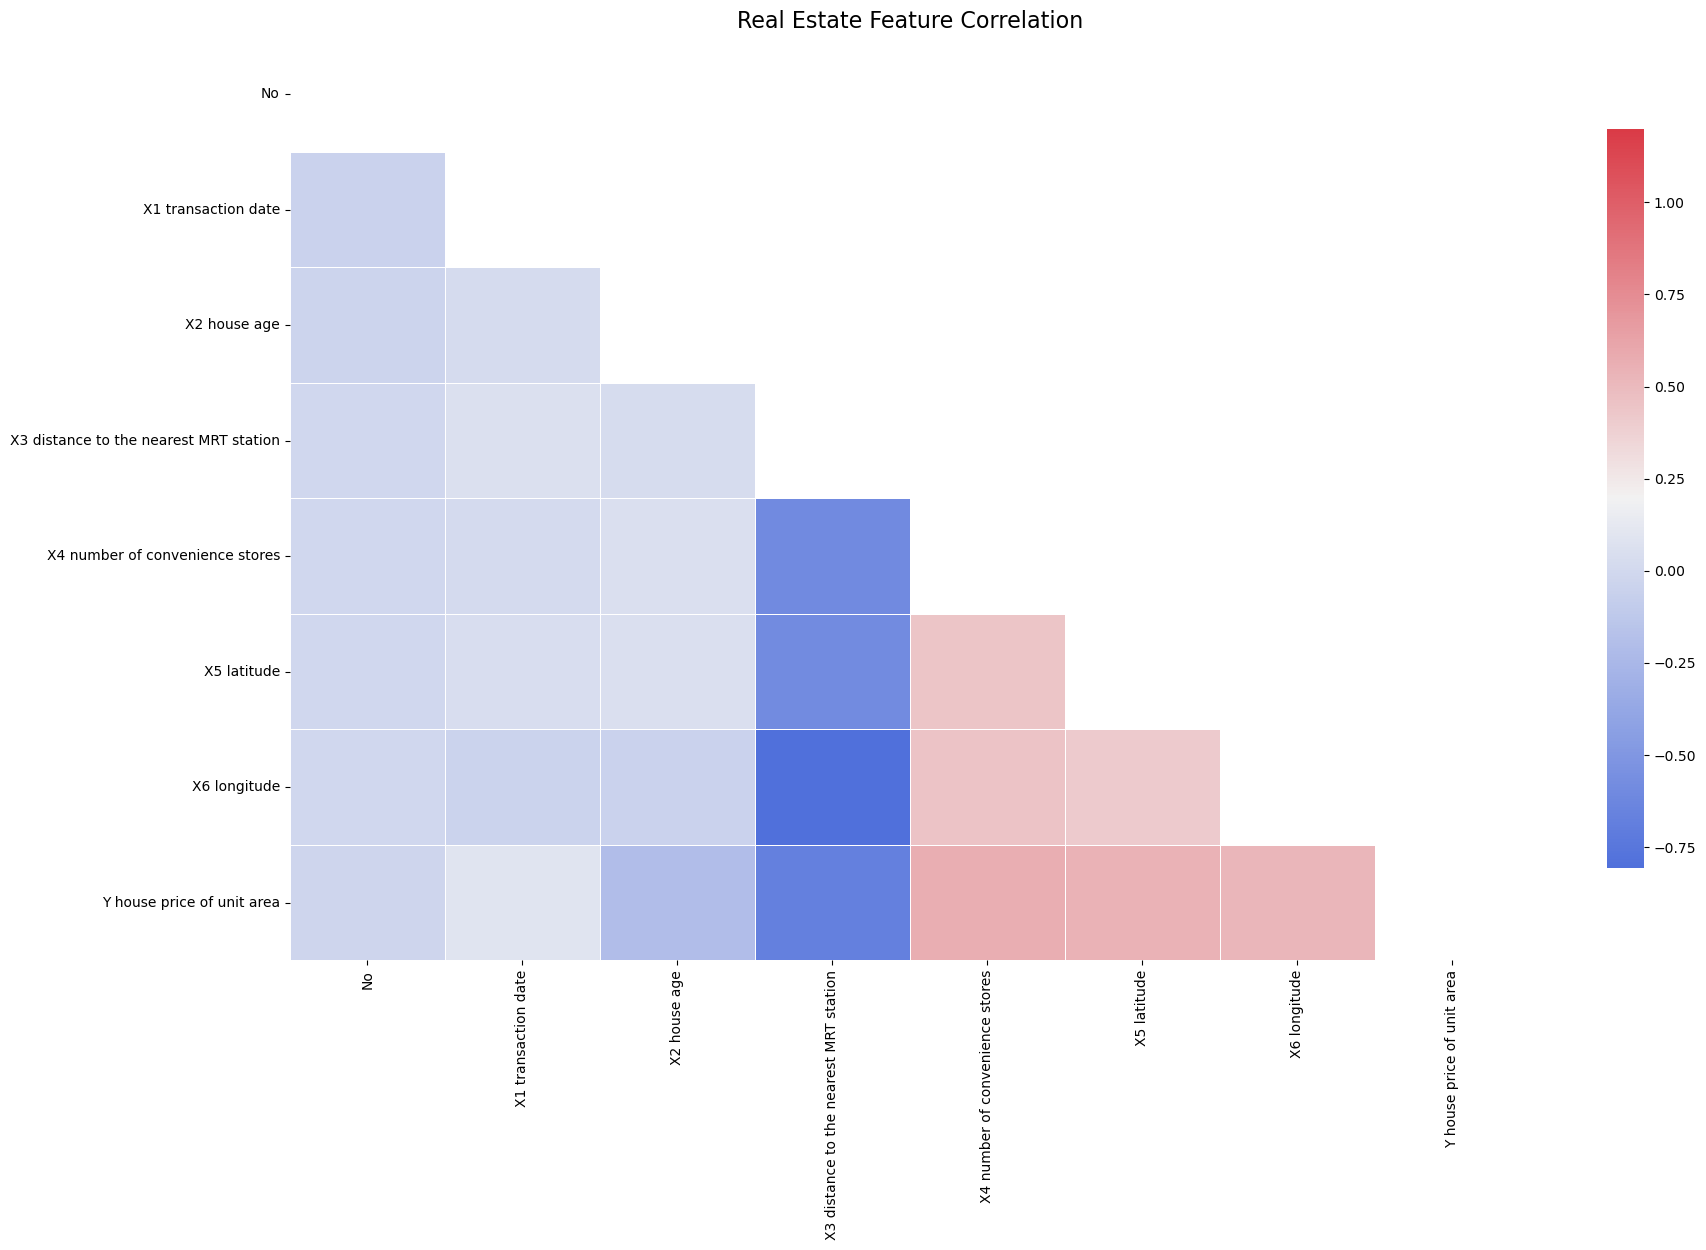

In [12]:
corrMatt = df.corr(numeric_only=True)

mask = np.zeros_like(corrMatt)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(20, 12))
plt.title('Real Estate Feature Correlation', fontsize=16)

cmap = sns.diverging_palette(260, 10, as_cmap=True)

sns.heatmap(
    corrMatt,
    mask=mask,
    cmap=cmap,
    vmax=1.2,
    square=False,
    annot=False,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.show()


### Model training and evaluation

#### Linear Regression

In [13]:
# Linear Regression
from sklearn.linear_model import LinearRegression

# Create the model
lin_reg_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lin_reg', LinearRegression())
])

# Train the model on the training data
lin_reg_model.fit(X_train, y_train)
# Predict probabilities return the predicted probability for each class
y_pred = lin_reg_model.predict(X_test)

# Evaluate the model on test data
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('Linear Regression Test RMSE: {:03.3f}'.format(test_rmse))
print('Relative RMSE(%): {:03.3f}'.format((test_rmse / y_pred.mean()) * 100))

# Perform K-Fold Cross-Validation
lin_reg_cv_scores = cross_val_score(lin_reg_model, X, y, cv=cv, scoring='neg_mean_squared_error')

#Convert to +ve scores
lin_reg_cv_scores = np.sqrt(-lin_reg_cv_scores)

print_cv_scores("Linear Regression", lin_reg_cv_scores)

Linear Regression Test RMSE: 8.606
Relative RMSE(%): 23.132
Linear Regression 5-Fold CV Scores Results:
    Mean RMSE: 8.924
    Standard Deviation of RMSE: 1.328



#### Support Vector Regression (SVR)

In [14]:
# Support Vector Machine Regression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create the model
svr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(C=1.0, kernel='rbf', degree=3, gamma='scale'))
])

# Train the model on the training data
svr_model.fit(X_train, y_train)
# Predict probabilities return the predicted probability for each class
y_pred = svr_model.predict(X_test)

# Evaluate the model on test data
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('SVR Test RMSE: {:03.3f}'.format(test_rmse))
print('Relative RMSE(%): {:03.3f}'.format((test_rmse / y_pred.mean()) * 100))

# Perform K-Fold Cross-Validation
svr_cv_scores = cross_val_score(svr_model, X, y, cv=cv, scoring='neg_mean_squared_error')

# Convert to +ve scores
svr_cv_scores = np.sqrt(-svr_cv_scores)

print_cv_scores("SVR", svr_cv_scores)

SVR Test RMSE: 8.152
Relative RMSE(%): 22.618
SVR 5-Fold CV Scores Results:
    Mean RMSE: 8.567
    Standard Deviation of RMSE: 1.300



#### Decision Tree

In [15]:
# Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor

# Create the model
tree_reg_model = DecisionTreeRegressor(random_state=42)

# Train the model on the training data
tree_reg_model.fit(X_train, y_train)
# Predict probabilities return the predicted probability for each class
y_pred = tree_reg_model.predict(X_test)

# Evaluate the model on the test data
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('Decision Tree Regressor Test RMSE: {:03.3f}'.format(test_rmse))
print('Relative RMSE(%): {:03.3f}'.format((test_rmse / y_pred.mean()) * 100))

# Perform K-Fold Cross-Validation
tree_reg_cv_scores = cross_val_score(tree_reg_model, X, y, cv=cv, scoring='neg_mean_squared_error')

# Convert to +ve scores
tree_reg_cv_scores = np.sqrt(-tree_reg_cv_scores)

print_cv_scores("Decision Tree Regressor", tree_reg_cv_scores)

Decision Tree Regressor Test RMSE: 8.215
Relative RMSE(%): 22.947
Decision Tree Regressor 5-Fold CV Scores Results:
    Mean RMSE: 9.827
    Standard Deviation of RMSE: 1.508



#### Multi-Layer Perceptron (Neural Network)

In [ ]:
# MLP Regression
from sklearn.neural_network import MLPRegressor

# Create the model
mlp_reg_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPRegressor(random_state=1, max_iter=10000, hidden_layer_sizes=(100,)))
])

# Train the model on the training data
mlp_reg_model.fit(X_train, y_train)
# Predict probabilities return the predicted probability for each class
y_pred = mlp_reg_model.predict(X_test)

# Evaluate the model on the test data
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('MLP Regressor Test RMSE: {:03.3f}'.format(test_rmse))
print('Relative RMSE(%): {:03.3f}'.format((test_rmse / y_pred.mean()) * 100))

# Perform K-Fold Cross-Validation
mlp_reg_cv_scores = cross_val_score(mlp_reg_model, X, y, cv=cv, scoring='neg_mean_squared_error')

# Convert to +ve scores
mlp_reg_cv_scores = np.sqrt(-mlp_reg_cv_scores)

print_cv_scores("MLP Regressor", mlp_reg_cv_scores)

### Regression Evaluation

The table below summarises the average accuracy and standard deviation across 5 cross-validation folds for each model.

A bar chart shows the relative performance.

In [ ]:
# Model Performance Summary Table

mean_y = y.mean()

relative_rmse_lin_reg = (lin_reg_cv_scores.mean() / mean_y) * 100
relative_rmse_svr = (svr_cv_scores.mean() / mean_y) * 100
relative_rmse_tree_reg = (tree_reg_cv_scores.mean() / mean_y) * 100
relative_rmse_mlp = (mlp_reg_cv_scores.mean() / mean_y) * 100

relative_std_lin_reg = (lin_reg_cv_scores.std() / mean_y) * 100
relative_std_svr = (svr_cv_scores.std() / mean_y) * 100
relative_std_tree_reg = (tree_reg_cv_scores.std() / mean_y) * 100
relative_std_mlp = (mlp_reg_cv_scores.std() / mean_y) * 100

summaryReg = pd.DataFrame([
    {"Model": "Linear Regression", "K": k, "Mean RMSE": lin_reg_cv_scores.mean(),  "Std Dev": lin_reg_cv_scores.std(), "Relative RMSE (%)": relative_rmse_lin_reg, "Relative Std Dev (%)": relative_std_lin_reg},
    {"Model": "SVR (RBF)", "K": k, "Mean RMSE": svr_cv_scores.mean(), "Std Dev": svr_cv_scores.std(), "Relative RMSE (%)": relative_rmse_svr, "Relative Std Dev (%)": relative_std_svr},
    {"Model": "Decision Tree", "K": k, "Mean RMSE": tree_reg_cv_scores.mean(), "Std Dev": tree_reg_cv_scores.std(), "Relative RMSE (%)": relative_rmse_tree_reg, "Relative Std Dev (%)": relative_std_tree_reg},
    {"Model": "MLP", "K": k, "Mean RMSE": mlp_reg_cv_scores.mean(), "Std Dev": mlp_reg_cv_scores.std(), "Relative RMSE (%)": relative_rmse_mlp, "Relative Std Dev (%)": relative_std_mlp},
]).sort_values("Mean RMSE", ascending=False).reset_index(drop=True)

summaryReg

,Model,K,Mean RMSE,Std Dev,Relative RMSE (%),Relative Std Dev (%)
0,Decision Tree,5,9.827042,1.507633,25.874122,3.969525
1,Linear Regression,5,8.923987,1.327790,23.496424,3.496006
2,SVR (RBF),5,8.567276,1.300091,22.557222,3.423077
3,MLP,5,7.964828,1.590213,20.971004,4.186954


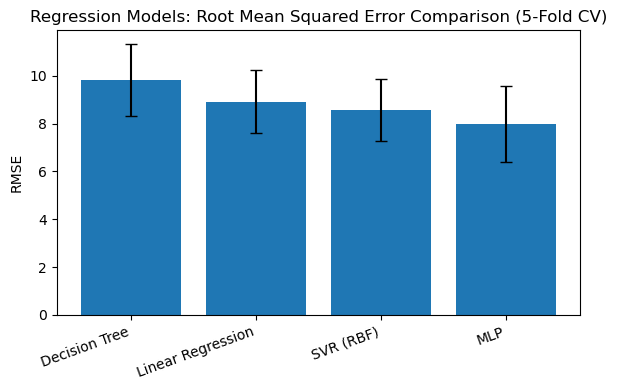

In [ ]:
# Model Performance Data Visualisation
plt.figure(figsize=(6,4))
plt.bar(summaryReg["Model"], summaryReg["Mean RMSE"], yerr=summaryReg["Std Dev"], capsize=4)
plt.ylabel("RMSE")
plt.title(f"Regression Models: Root Mean Squared Error Comparison ({k}-Fold CV)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()